In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
from scipy.io import loadmat

In [54]:
mat = loadmat('priors.mat')
len(mat['Priors'][0][0])
names = [str(i[0][0]) for i in mat["Priors"][0][0][2]]

mat['Priors'][0][0][1]

array([[0.8       , 0.        , 0.06666667, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.2       , 0.        ,
        0.13333333],
       [0.        , 0.        , 0.        , ..., 0.        , 0.04444444,
        0.11111111],
       ...,
       [0.        , 0.02222222, 0.53333333, ..., 0.        , 0.        ,
        0.        ],
       [0.02222222, 0.06666667, 0.57777778, ..., 0.        , 0.        ,
        0.        ],
       [0.04444444, 0.02222222, 0.53333333, ..., 0.        , 0.        ,
        0.        ]], shape=(59412, 20))

In [46]:
## collapse results from individual files into a single file

datapath = Path('./sim_results')
files = list(datapath.glob('*csv'))
print(f'found {len(files)} files')

header = None
datarows = []

for file in files:
    with open(file, 'r') as f:
        f_lines = f.readlines()
    if header is None:
        header = f_lines[0]
    datarows.append(f_lines[1])

header_networks = header.strip().split(',')[:3] + names
print(len(header_networks))
header_str = ','.join(header_networks)
print(header_str)
with open('sim_results.csv', 'w') as f:
    f.write(header_str)
    for row in datarows:
        f.write(row)
print(len(row.split(',')))

found 901 files
24
,noise_level,ari,Default_Parietal,Default_Anterolateral,Default_Dorsolateral,Default_Retrosplenial,Visual_Lateral,Visual_Dorsal/VentralStream,Visual_V5,Visual_V1,Frontoparietal,DorsalAttention,Premotor/DorsalAttentionII,Language,Salience,CinguloOpercular/Action-mode,MedialParietal,Somatomotor_Hand,Somatomotor_Face,Somatomotor_Foot,Auditory,SomatoCognitiveAction,Noise
23


In [42]:
df = pd.read_csv('sim_results.csv')
df.head()

,Unnamed: 0,noise_level,ari,Default_Parietal,Default_Anterolateral,Default_Dorsolateral,Default_Retrosplenial,Visual_Lateral,Visual_Dorsal/VentralStream,Visual_V5,...,1258,2156,1174,2388,942,1224,0,1038,1274,841
0,0,0.30,0.789117,2182,4082,1761,1365,0,1244,617,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0.10,0.798555,2182,2079,0,1365,1207,0,617,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,0.25,0.821841,3943,0,0,1365,1207,1244,617,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,0.25,0.883863,2182,3286,3035,1365,0,2282,617,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,0.15,1.000000,2182,2079,1761,1365,1207,1244,617,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
df = pd.read_csv('sim_results.csv')
del df['Unnamed: 0']
# save a copy of the ari data
df_ari = df[['noise_level', 'ari']]
del df['ari']

df.head()

,noise_level,Default_Parietal,Default_Anterolateral,Default_Dorsolateral,Default_Retrosplenial,Visual_Lateral,Visual_Dorsal/VentralStream,Visual_V5,Visual_V1,Frontoparietal,...,1258,2156,1174,2388,942,1224,0,1038,1274,841
0,0.30,2182,4082,1761,1365,0,1244,617,2688,4484,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.10,2182,2079,0,1365,1207,0,617,1464,4096,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.25,3943,0,0,1365,1207,1244,617,1464,2335,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.25,2182,3286,3035,1365,0,2282,617,1464,2335,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.15,2182,2079,1761,1365,1207,1244,617,1464,2335,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
# convert from wide to long

df_long = pd.melt(df, id_vars=['noise_level'], var_name='module', value_name='size').query('noise_level < .5')
df_long = df_long.query('noise_level < .45')
df_long.head()

,noise_level,module,size
0,0.30,Default_Parietal,2182.0
1,0.10,Default_Parietal,2182.0
2,0.25,Default_Parietal,3943.0
3,0.25,Default_Parietal,2182.0
4,0.15,Default_Parietal,2182.0


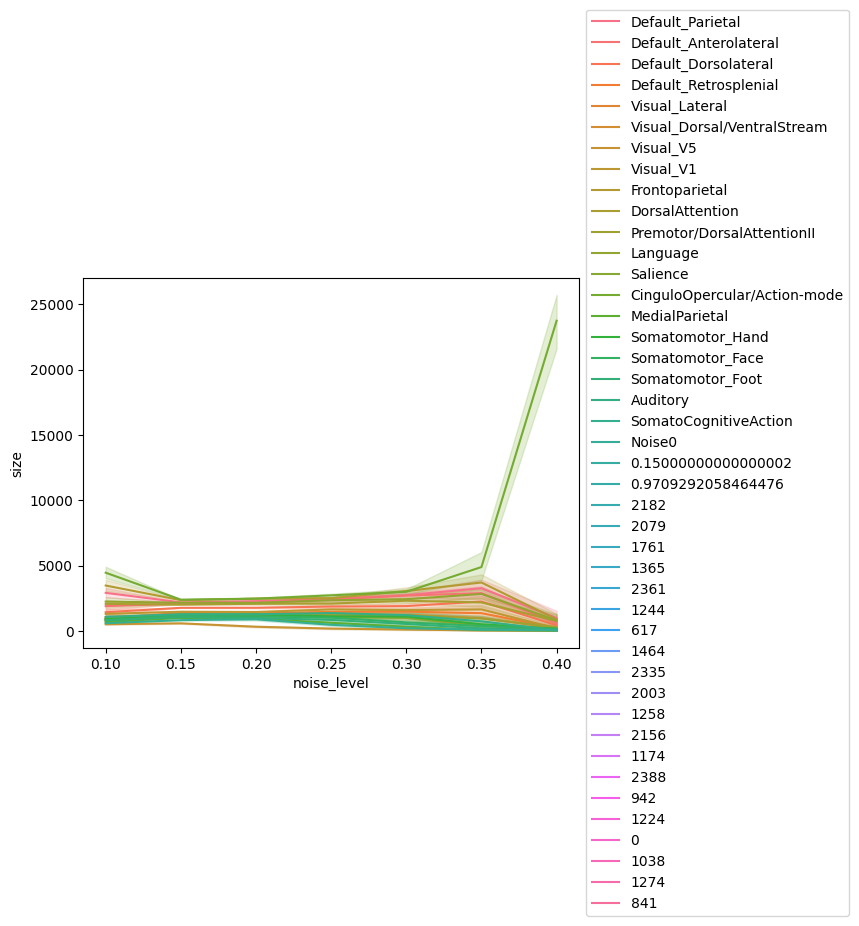

In [39]:
sns.lineplot(x='noise_level', y='size', hue='module', data=df_long)
# put the legend to the right, outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [5]:
print(df.iloc[0, 1:].sum())
print(df.iloc[0, 1:].min())
print(df.iloc[0, 1:].max())


29706.0
617.0
2388.0
